In [1]:
import numpy as np
from simulation import Simulation

In [2]:
sim = Simulation(threads=10)

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

In [15]:
s_list = np.linspace(0, sim.length, 26, endpoint=False)
strength_list = 1e-3 * np.cos(13 * 2*np.pi * s_list / sim.line.get_length())
sim.add_dipole(strength=strength_list, s=s_list, mode='skew') # normal

Slicing line:   0%|          | 0/4570 [00:00<?, ?it/s]

In [4]:
sim.set_up(n_particles = 1,#int(1e3),
          n_turns = 50,
          n_monitors = 100,
          nemitt_x_0=2e-5,
          nemitt_y_0=2e-5)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Slicing line:   0%|          | 0/3980 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [5]:
sim.run(spacecharge=False, beam_intensity=2e11, n_interactions=200, xfields=False, indirect_spacecharge=False)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [6]:
sim.save('centroid_on_co_sc')

File saved at data/centroid_on_co_sc


/home/rsimpson/MPhys Project/Code/Accelerator Simulation/simulation.py:194: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['W_matrix'], dtype='str')]

  df_twiss.to_hdf(f'data/{filename}.h5', key='twiss_data',


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=()`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  value = self._g_getattr(self._v_node, name)


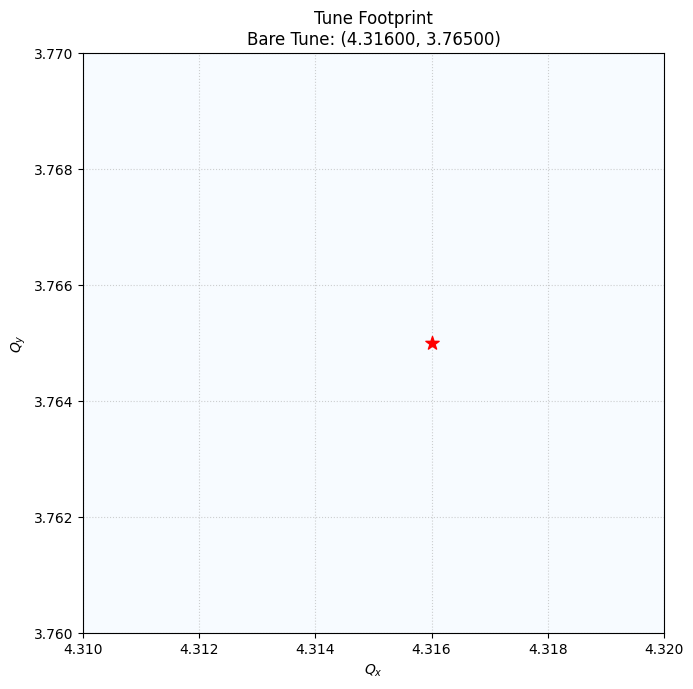

AttributeError: 'Analysis' object has no attribute 'x_pipe'

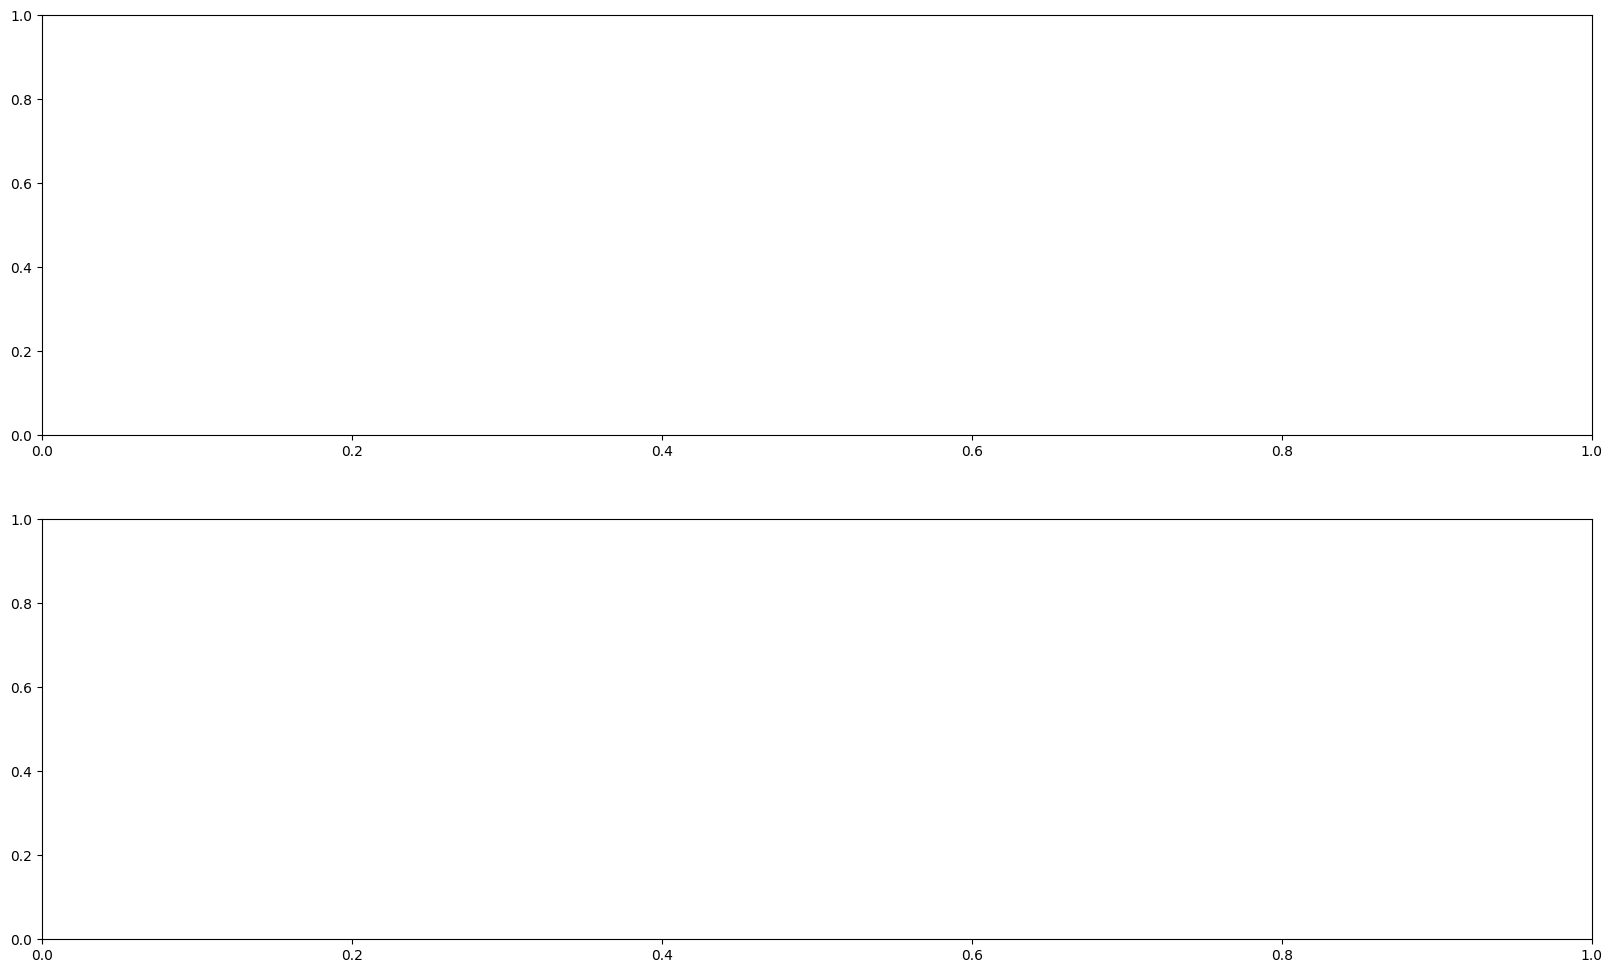

In [8]:
import numpy as np
import matplotlib.pyplot as plt 

from analysis import Analysis
analysis= Analysis('centroid_on_co_sc')
analysis.tune_histogram(x_lims=(4.31, 4.32), y_lims=(3.76,3.77))
#analysis.plot_ensemble_fft_spectrum('x')
#analysis.plot_ensemble_fft_spectrum('y')
analysis.plot_field_in_pipe()
#plt.plot(analysis.x0)
print(analysis.Qx_centroid, analysis.Qy_centroid)

In [ ]:
mon_mask = analysis.df_twiss['name'].str.contains('mon')
df_mon = analysis.df_twiss[mon_mask]

x  = np.linspace(0, 163, 100, endpoint=False)
plt.plot(x, np.mean(analysis.x, axis=0)[0:100])
plt.plot(x, 1e7*(df_mon.x))

plt.ylabel('closed orbit')
plt.xlabel('s')
print(np.mean(analysis.x, axis=0)[0:0+100][1])
plt.show()
plt.plot(analysis.df_twiss.x.values)

In [ ]:
plt.plot(np.std(analysis.x, axis=0)[0:100])
plt.plot(analysis.sigma_x)
plt.show()
plt.plot(np.std(analysis.y, axis=0)[0:100])
plt.plot(analysis.sigma_y)
plt.show()

In [32]:
import xpart as xp
sim.line
p = xp.Particles('proton', p0c=1e9)

In [33]:
tw = sim.line.twiss(method='4d')

In [34]:
p.x[0]=tw.x[0]
p.y[0]=tw.y[0]
p.px[0]=tw.px[0]
p.py[0]=tw.py[0]

In [35]:
sim.line.track(p, freeze_longitudinal=True)

In [36]:
p

Particles(q0=1, mass0=9.38e+08, p0c=[1.e+09], gamma0=[1.46147392], beta0=[0.7292562], s=[0.], zeta=[0.], x=[-2.43819485e-06], y=[-0.00074132], px=[-1.30325981e-07], py=[-0.00087012], ptau=[0.], delta=[0.], rpp=[1.], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[2212], particle_id=[0], at_element=[0], at_turn=[1], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0)

In [37]:
[print(i) for i in sim.line.elements if 'avity' in str(i)]

[]

In [38]:
print(tw.x[0])

-2.4381948863979307e-06
